## Step 1 : Import the libraries

In [1]:
import os                        # lets Python see folders and files
import zipfile                   # lets Python open .zip files
import pandas as pd              # the main tool for tables
import matplotlib.pyplot as plt  # the tool for drawing charts

print("Libraries loaded!")

Libraries loaded!


In [2]:
print(os.getcwd())                  # should now end in /TenderLens/notebooks
print(os.listdir("../data/raw"))    # should show the zip file name

/Users/sindhusharma/Documents/TenderLens/notebooks
['tenders', 'raw_data_fy_2016_2022.zip', 'PUT_ZIP_HERE.txt']


In [3]:
print(os.getcwd())
print(os.listdir("../data/raw"))

/Users/sindhusharma/Documents/TenderLens/notebooks
['tenders', 'raw_data_fy_2016_2022.zip', 'PUT_ZIP_HERE.txt']


## Step 2 : Unzip the data

In [4]:
zip_path = "../data/raw/raw_data_fy_2016_2022.zip"   # where the zip file is
unzip_folder = "../data/raw/tenders"                 # where we want the files to go

if not os.path.exists(unzip_folder):          # if we have NOT unzipped before...
    with zipfile.ZipFile(zip_path) as z:      # ...open the zip
        z.extractall(unzip_folder)            # ...and take everything out
    print("Unzipped the data.")
else:
    print("Already unzipped - skipping.")

Already unzipped - skipping.


## Step 3 · Count the files


In [5]:
data_folder = unzip_folder + "/concatinated_csvs"    # the folder that holds all the CSV files

all_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]   # keep only .csv files
print("Total files:", len(all_files))

newer_files = [f for f in all_files if f.startswith("final_")]       # names starting with final_
older_files = [f for f in all_files if not f.startswith("final_")]   # all the rest
print("Older files:", len(older_files))
print("Newer files:", len(newer_files))

Total files: 39500
Older files: 30291
Newer files: 9209


## Step 4 · Look at one file
Before reading all files, we open one newer file to understand its structure: how many rows and columns it has, and where the useful information is.

In [6]:
example = pd.read_csv(data_folder + "/" + newer_files[0], encoding="utf-8-sig")   # read the first newer file

print("File name:", newer_files[0])
print("Rows:", example.shape[0], "  Columns:", example.shape[1])   # shape = (rows, columns)
example.head(3)                                                    # show the first 3 rows

File name: final_2022_GMC_28546_35.csv
Rows: 4   Columns: 77


,Organisation Chain :,Tender ID :,Tender Ref No :,Tender Title :,Type :,Summary :,Updated By :,Updated On :,Document :,S.No,...,Document Download / Sale Start Date,Document Download / Sale End Date,Clarification Start Date,Clarification End Date,Bid Submission Start Date,Bid Submission End Date,S.No.1,Corrigendum Title,Corrigendum Type,View
0,Guwahati Municipal Corporation,2022_GMC_28546_35,GER/CE/1806/2019/241 Dated-19/12/2022,Construction of Road and drain at Binoy Kumar ...,Technical,Bid has been Opened and Admitted for Technical...,Doni Hatimuria,24-Jan-2023 01:12 AM,NaN,1.0,...,07-Jan-2023 09:05 AM,17-Jan-2023 02:00 PM,NA,NA,12-Jan-2023 09:00 AM,17-Jan-2023 02:00 PM,1.0,Technical,Technical Bid,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 5 · Read every file
First we practise on one file: pick the useful details from row 0 and count the bidders. Then we repeat it for all 39,500 files.

### Step 5a · Take the tender details from one file

In [7]:
row = {                                                     # an empty "form" we fill in
    "tender_id": example["Tender ID"].iloc[0],              # .iloc[0] = take the value from row 0
    "title": example["Title"].iloc[0],
    "department": example["Organisation Chain"].iloc[0],
    "category": example["Tender Category"].iloc[0],
    "estimated_value": example["Tender Value in ₹"].iloc[0],
    "published_date": example["Publish Date"].iloc[0],
    "last_date": example["Bid Submission End Date"].iloc[0],
}

row        # show the filled-in form

{'tender_id': '2022_GMC_28546_35',
 'title': 'Construction of Road and drain at Binoy Kumar Tamuli path at byelane no. 4',
 'department': 'Guwahati Municipal Corporation',
 'category': 'Works',
 'estimated_value': '43,00,000',
 'published_date': '07-Jan-2023 09:00 AM',
 'last_date': '17-Jan-2023 02:00 PM'}

### Step 5b · Count the bidders in one file
Bidder names are listed one per row. We drop the empty rows and count the names.
If the tender was awarded, the full list is in `Bidder Name.1` (because `Bidder Name` then holds only the winner).

In [8]:
# 1. choose the right column
if "Awarded Value" in example.columns:        # was a winner chosen?
    bidder_column = "Bidder Name.1"           # yes -> the full list is here
else:
    bidder_column = "Bidder Name"             # no  -> the list is here

# 2. take the names and remove empty rows
bidders = example[bidder_column].dropna()     # dropna() = drop the empty (NaN) rows

# 3. count them
number_of_bids = bidders.nunique()            # nunique() = count each different name once

print("Column used:", bidder_column)
print("Bidders:", list(bidders))
print("Number of bids:", number_of_bids)

Column used: Bidder Name
Bidders: ['HRISHIKESH TALUKDAR', 'M/S MAZUMDER CONSTRUCTION', 'SARAT DEKA']
Number of bids: 3


### Step 5c · A helper for missing columns
Not every file has every column (older files have no bidder list). This helper returns the row-0 value if the column exists, or `None` if it doesn't, so the code never crashes.

In [9]:
def first_value(table, column):          # "def" = define (build) a function
    if column in table.columns:          # does this column exist in the file?
        return table[column].iloc[0]     # yes -> give back the value in row 0
    return None                          # no  -> give back None (empty)

# test it on our example file
print(first_value(example, "Title"))            # this column exists
print(first_value(example, "Awarded Value"))    # this column does NOT exist in this file

Construction of Road and drain at Binoy Kumar Tamuli path at byelane no. 4
None


### Step 5d · Read all 39,500 files
We loop over every file: take the tender details from row 0, count the bidders, and store one "form" (dictionary) per tender in a list. Older files have no bidder list, so their bid count stays empty (not zero).

In [10]:
rows = []                                            # the "done" pile - starts empty

for i, file_name in enumerate(all_files):            # go through every file, one by one
    table = pd.read_csv(data_folder + "/" + file_name, encoding="utf-8-sig", dtype=str)

    # --- 1. tender details (row 0) ---
    row = {
        "file_name": file_name,
        "file_type": "newer" if file_name.startswith("final_") else "older",
        "tender_id": first_value(table, "Tender ID"),
        "reference_no": first_value(table, "Tender Reference Number"),
        "department": first_value(table, "Organisation Chain"),
        "title": first_value(table, "Title"),
        "work_description": first_value(table, "Work Description"),
        "category": first_value(table, "Tender Category"),
        "product_category": first_value(table, "Product Category"),
        "tender_type": first_value(table, "Tender Type"),
        "contract_form": first_value(table, "Form of contract"),
        "estimated_value": first_value(table, "Tender Value in ₹"),
        "emd_amount": first_value(table, "EMD Amount in ₹"),
        "tender_fee": first_value(table, "Tender Fee in ₹"),
        "published_date": first_value(table, "Publish Date"),
        "last_date": first_value(table, "Bid Submission End Date"),
        "bid_opening_date": first_value(table, "Bid Opening Date"),
        "work_period_days": first_value(table, "Period Of Work(Days)"),
        "location": first_value(table, "Location"),
    }

    # --- 2. amendments: count rows that have a corrigendum title ---
    if "Corrigendum Title" in table.columns:
        row["amendment_count"] = table["Corrigendum Title"].notna().sum()
    else:
        row["amendment_count"] = 0

    # --- 3. was it cancelled? (some files have a column with "Cancelled" in its name) ---
    row["cancelled"] = any("Cancelled" in column for column in table.columns)

    # --- 4. bidders (same logic as Step 5b) ---
    has_award = "Awarded Value" in table.columns
    row["has_award"] = has_award

    if has_award:
        bidder_column = "Bidder Name.1"
    elif "Bidder Name" in table.columns:
        bidder_column = "Bidder Name"
    else:
        bidder_column = None                         # older file: no bidder list

    if bidder_column is not None:
        row["number_of_bids"] = table[bidder_column].dropna().nunique()
    else:
        row["number_of_bids"] = None                 # unknown - NOT zero

    # --- 5. award details (only some newer files) ---
    row["awarded_value"] = first_value(table, "Awarded Value") if has_award else None
    row["winning_supplier"] = first_value(table, "Bidder Name") if has_award else None

    rows.append(row)                                 # put the form on the "done" pile

    if i % 5000 == 0:                                # every 5,000 files...
        print("Read", i, "files so far...")          # ...show progress

print("Finished! Read", len(rows), "files.")

Read 0 files so far...
Read 5000 files so far...
Read 10000 files so far...
Read 15000 files so far...
Read 20000 files so far...
Read 25000 files so far...
Read 30000 files so far...
Read 35000 files so far...
Finished! Read 39500 files.


## Step 6 · Put everything into one table
We turn the list of forms into a pandas DataFrame called `master`: one row per tender, one column per detail.

In [11]:
master = pd.DataFrame(rows)        # turn the list of forms into a table

print("Rows:", master.shape[0], "  Columns:", master.shape[1])
master.head()                      # show the first 5 rows

Rows: 39500   Columns: 25


,file_name,file_type,tender_id,reference_no,department,title,work_description,category,product_category,tender_type,...,last_date,bid_opening_date,work_period_days,location,amendment_count,cancelled,has_award,number_of_bids,awarded_value,winning_supplier
0,2020_PWD_16002_215_0.csv,older,2020_PWD_16002_215,CE/Maint/A.D./404/2019/2,Public Works Roads Department,Dhu/AD19-20/23 Improvement and upgradation of ...,Dhu/AD19-20/23 Improvement and upgradation of ...,Works,Civil Works,Open Tender,...,05-Feb-2020 04:00 PM,06-Feb-2020 02:00 PM,270.0,Dhubri,2,False,False,NaN,NaN,NaN
1,2020_PWD_15864_63_0.csv,older,2020_PWD_15864_63,CE/DEV/TB/199/2019-20/01,Public Works Roads Department,SOPD_SIG_19_20_63,SOPD_SIG_19_20_63 Improvement of road from Kar...,Works,Civil Works,Open Tender,...,05-Feb-2020 02:00 PM,05-Feb-2020 02:10 PM,270.0,Dhemaji,1,False,False,NaN,NaN,NaN
2,final_2022_GMC_28546_35.csv,newer,2022_GMC_28546_35,GER/CE/1806/2019/241 Dated-19/12/2022,Guwahati Municipal Corporation,Construction of Road and drain at Binoy Kumar ...,Improvement of Various works under Guwahati Mu...,Works,Civil Works – Roads,Open Tender,...,17-Jan-2023 02:00 PM,17-Jan-2023 02:30 PM,90.0,Guwahati,1,False,False,3.0,NaN,NaN
3,2018_PWD_9253_77_0.csv,older,2018_PWD_9253_77,CT-82/89/2016/36,Public Works Roads Department,SOPD_DH_32,Construction of Guru Teg Bahadur road to Kalab...,Works,Civil Works – Roads,Open Tender,...,23-Nov-2018 02:00 PM,27-Nov-2018 10:00 AM,120.0,DHUBRI,0,False,False,NaN,NaN,NaN
4,final_2022_PCCF_28162_1.csv,newer,2022_PCCF_28162_1,JRT/SOPD/ROAD AND BRIDGES/2022-23/06,Pr. Chief Conservator of Forest and Head of Fo...,IMPROVEMENT OF MELENG KATHALGURI ROAD,IMPROVEMENT OF MELENG KATHALGURI ROAD HOLLONGA...,Works,Civil Works,Open Tender,...,05-Jan-2023 04:00 PM,06-Jan-2023 11:30 AM,60.0,MELENG KATHALGURI HOLLONGAPAR GIBBON SANCTUARY,1,False,False,1.0,NaN,NaN


## Step 7 · Check the key numbers
We check for duplicate tenders, count the tenders where we know the number of bids, and calculate the single-bid rate.

### Code cell 1 · duplicates

In [12]:
print("Total rows:          ", len(master))
print("Unique tender IDs:   ", master["tender_id"].nunique())          # how many different IDs
print("Duplicate tender IDs:", master["tender_id"].duplicated().sum())  # how many repeats

Total rows:           39500
Unique tender IDs:    39411
Duplicate tender IDs: 89


### Code cell 2 · labelled tenders and the single-bid rate

In [13]:
labelled = master[master["number_of_bids"] >= 1]       # keep only tenders with at least 1 known bid

single = labelled["number_of_bids"] == 1                # True if exactly one bid, False otherwise

print("Labelled tenders: ", len(labelled))
print("Single-bid:       ", single.sum())               # True counts as 1, so sum() = how many True
print("Multi-bid:        ", (~single).sum())            # ~ means "NOT", so this counts the False ones
print("Single-bid rate:   {:.1%}".format(single.mean()))   # mean of True/False = the share that is True

Labelled tenders:  6790
Single-bid:        2044
Multi-bid:         4746
Single-bid rate:   30.1%


### Insight · Duplicates and single-bid rate
- There are 39,500 tender files but only 39,411 different tender IDs, so 89 tenders appear twice.
- 6,790 tenders have at least one bidder recorded. Out of these, 2,044 got only one bid, which is 30.1%.
- So about 3 in every 10 tenders had no competition. That is common enough for a model to learn from, but not most tenders.
- A single bid is not proof that something is wrong. Some work is specialised and only a few companies can do it.
- Next: remove the 89 duplicates in S2 and check that the rate stays near 30%.

## Step 8 · Charts
### Chart 1 · The data funnel
How much of the data can be used to train the single-bid model?

### code cell 1 · load our style (only needed once per notebook):

In [14]:
import sys
sys.path.append("..")               # let Python look in the main TenderLens folder
from tenderlens_style import *      # load our colours and chart style

print("Style loaded!")

Style loaded!


### Code cell 2 · the funnel chart:

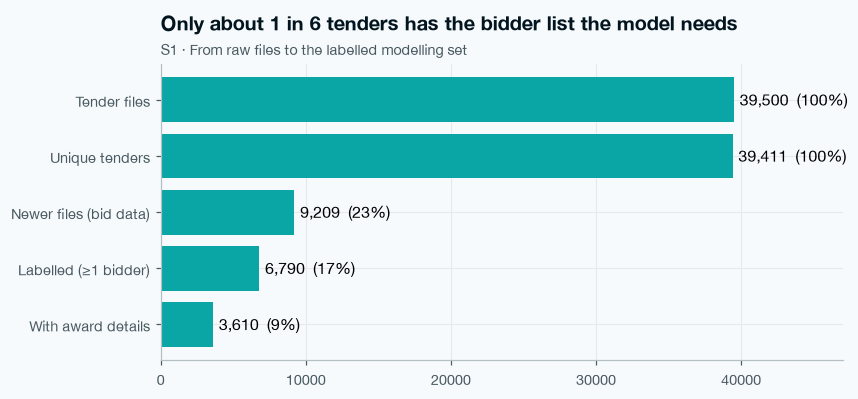

In [15]:
names = ["Tender files", "Unique tenders", "Newer files (bid data)", "Labelled (≥1 bidder)", "With award details"]
values = [
    len(master),                               # 39,500
    master["tender_id"].nunique(),             # 39,411
    (master["file_type"] == "newer").sum(),    # 9,209
    len(labelled),                             # 6,790
    master["has_award"].sum(),                 # 3,610
]

fig, ax = plt.subplots(figsize=(8, 3.5))                  # create an empty chart, 8 wide x 3.5 tall
bars = ax.barh(names[::-1], values[::-1], color=MULTI)    # horizontal bars; [::-1] flips the order so the biggest is on top

for bar, value in zip(bars, values[::-1]):                # write the number at the end of each bar
    ax.text(value + 400, bar.get_y() + 0.3, f"{value:,}  ({value / len(master):.0%})")

ax.set_xlim(0, 47000)                                     # leave room on the right for the labels
title(ax, "Only about 1 in 6 tenders has the bidder list the model needs",
          "S1 · From raw files to the labelled modelling set")
fig.savefig("../reports/figures/S1a_data_funnel.png")     # save the chart as a picture
plt.show()

### Insight · Data funnel
- Out of 39,500 tender files, only 6,790 (17%) have a bidder list, and only 3,610 (9%) have award details.
- Only these 6,790 tenders can teach the model the difference between single-bid and multi-bid tenders.
- The other tenders are still useful for history features, text analysis and finding unusual tenders.
- The bidder lists come almost only from the newer files, so the model will learn mostly from recent tenders.
- In S2 I will keep unknown bid counts as unknown, never as zero.

### Chart 2 · Tenders per year
When were the tenders published? We turn the text date into a real date and count tenders per year.

published_year
2016     571
2017    4961
2018    9318
2019    6004
2020    6723
2021    3060
2022    6293
2023    2570
Name: count, dtype: int64


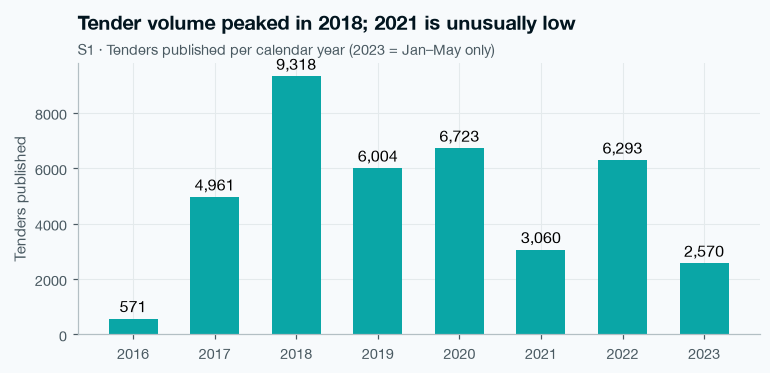

In [16]:
# 1. turn the text into a real date
master["published_date"] = pd.to_datetime(master["published_date"].str.strip(), format="%d-%b-%Y %I:%M %p")

# 2. take the year out of the date
master["published_year"] = master["published_date"].dt.year

# 3. count tenders per year, sorted by year
per_year = master["published_year"].value_counts().sort_index()
print(per_year)

# 4. draw the chart
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(per_year.index.astype(str), per_year.values, color=MULTI, width=0.6)   # vertical bars
ax.bar_label(bars, labels=[f"{v:,}" for v in per_year.values], padding=2)           # number on top of each bar
ax.set_ylabel("Tenders published")
title(ax, "Tender volume peaked in 2018; 2021 is unusually low",
          "S1 · Tenders published per calendar year (2023 = Jan–May only)")
fig.savefig("../reports/figures/S1b_tenders_per_year.png")
plt.show()

### Insight · Tenders per year
- The number of tenders was highest in 2018 (9,318). 2021 has only 3,060, about half of a normal year.
- Most of the drop is between March 2021 and February 2022, when almost no tenders appear in the data.
- This could be a real slowdown or a gap in the collected data, so I will check it in S2.
- 2016 starts in April and 2023 stops in May, so their lower counts are expected.

## Step 9 · Save the table
We save the raw master table to `data/interim/` so the cleaning notebook (S2) can start from it. Nothing has been cleaned yet.

In [17]:
master.to_csv("../data/interim/raw_master.csv", index=False)     # save the table as a CSV file

print("Saved", len(master), "rows to data/interim/raw_master.csv")

Saved 39500 rows to data/interim/raw_master.csv


## S1 Summary - Data Audit

### Starting point
- I downloaded the Assam e-tenders data from CivicDataLab (raw_data_fy_2016_2022.zip, about 72 MB).
- It has 39,500 CSV files. Each file is one tender, from April 2016 to May 2023.

### What I checked
- How each file is built: the first row has the tender details, and the extra rows hold lists like bidders and documents.
- Which files have a bidder list. 30,291 older files do not, and 9,209 newer files (names starting with "final_") do.
- How many tenders repeat, how many have bids, awards or cancellations.

### What I found
- 89 tender IDs appear twice, so there are 39,411 unique tenders.
- Only 6,790 tenders have at least one bidder recorded. These are the only ones I can use to learn single-bid patterns.
- 2,044 of them got only one bid, which is 30.1%.
- 3,610 tenders have an award, and 1,249 were cancelled before bids were opened.
- Tenders per year are uneven: 2018 is the biggest year (9,318) and 2021 is small (3,060). 2023 only covers January to May.

### Decisions made
- The target will be single bid (1) vs more than one bid (0), using only tenders with a bidder list.
- Unknown bid counts stay unknown. I will not treat them as 0.
- I will split the data by time (train up to Sep 2022, validation Oct to Dec 2022, test Jan to May 2023) so the model is tested on newer tenders.

### Files saved
- data/interim/raw_master.csv (39,500 rows, 26 columns)
- Charts S1a (data funnel) and S1b (tenders per year) in reports/figures

### Next steps (S2)
- Remove duplicate tenders.
- Turn text columns into proper numbers and dates.
- Create the single_bid target and other helpful columns.